In [1]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# Paths to stems
bass_file = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues/blues.00000/bass.wav"
drums_file = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues/blues.00000/drums.wav"
other_file = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues/blues.00000/other.wav"
vocals_file = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues/blues.00000/vocals.wav"

In [2]:
# Load stems
bass, sr = librosa.load(bass_file, sr=None)
drums, _ = librosa.load(drums_file, sr=sr)
other, _ = librosa.load(other_file, sr=sr)
vocals, _ = librosa.load(vocals_file, sr=sr)

In [3]:
# Combine stems
combined_audio = bass + drums + other + vocals
combined_audio = combined_audio / np.max(np.abs(combined_audio))

In [5]:
# Function to plot mel spectrogram
def plot_mel(audio, sr, title, n_mels=256):
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=n_mels
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        mel_db,
        sr=sr,
        x_axis='time',
        y_axis='mel'
    )
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.show()

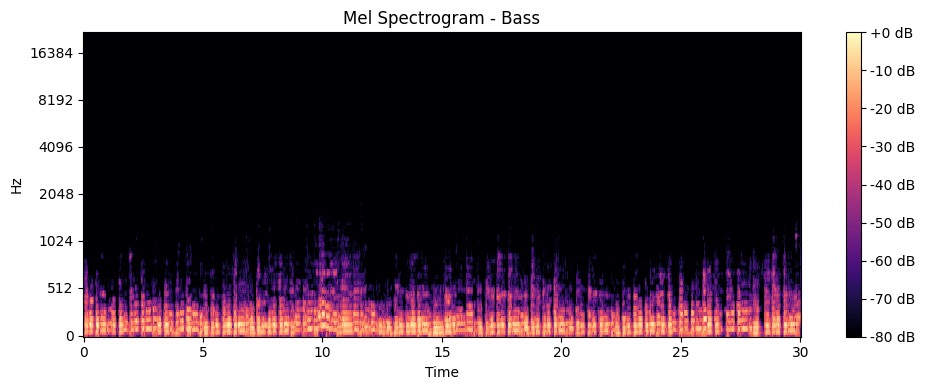

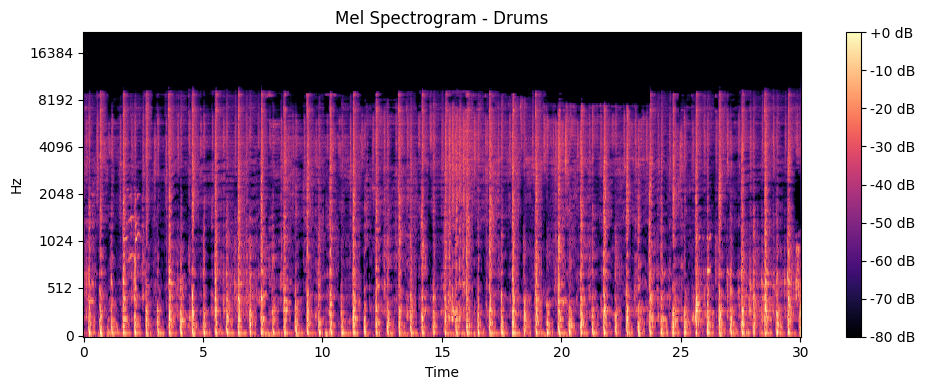

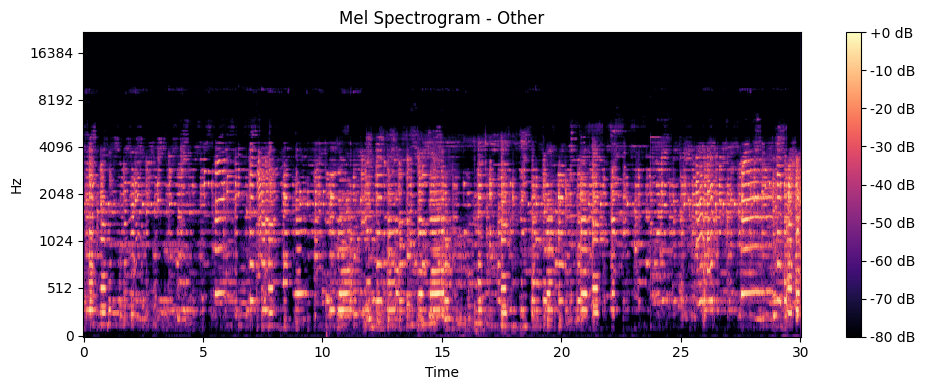

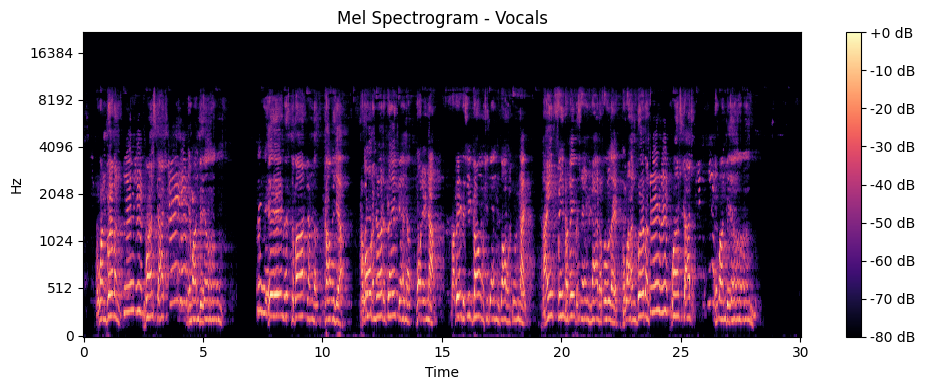

In [6]:
plot_mel(bass, sr, "Mel Spectrogram - Bass", n_mels=256)
plot_mel(drums, sr, "Mel Spectrogram - Drums", n_mels=256)
plot_mel(other, sr, "Mel Spectrogram - Other", n_mels=256)
plot_mel(vocals, sr, "Mel Spectrogram - Vocals", n_mels=256)

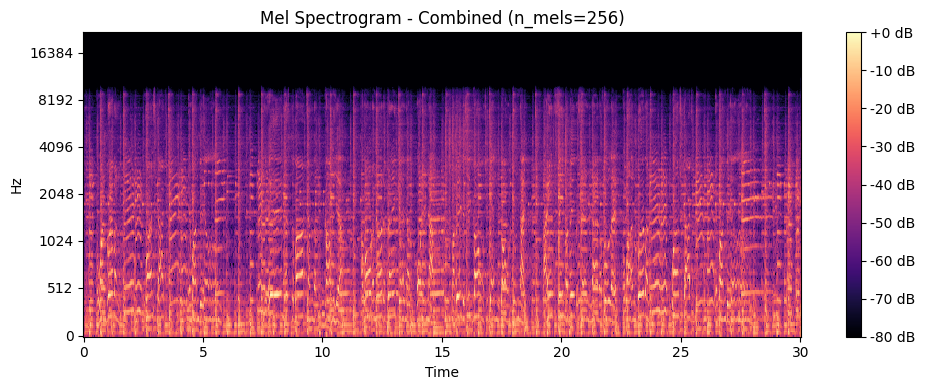

In [7]:
plot_mel(combined_audio, sr, "Mel Spectrogram - Combined (n_mels=256)", n_mels=256)

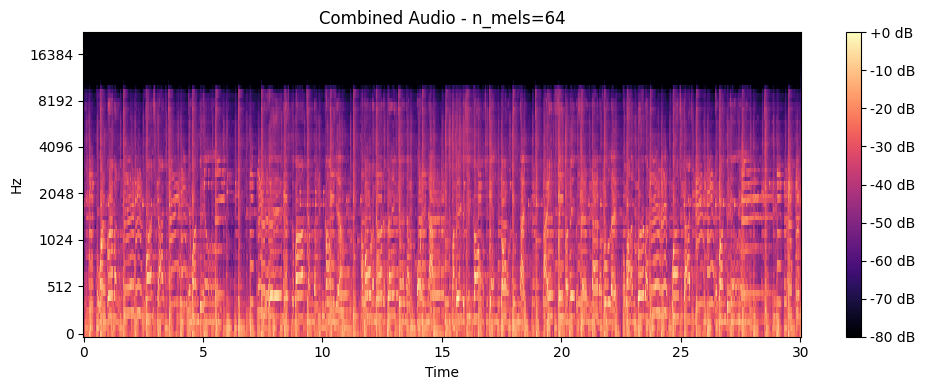

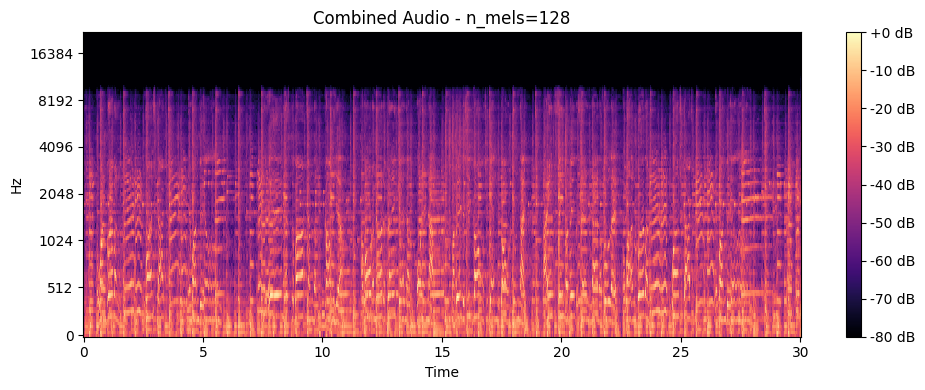

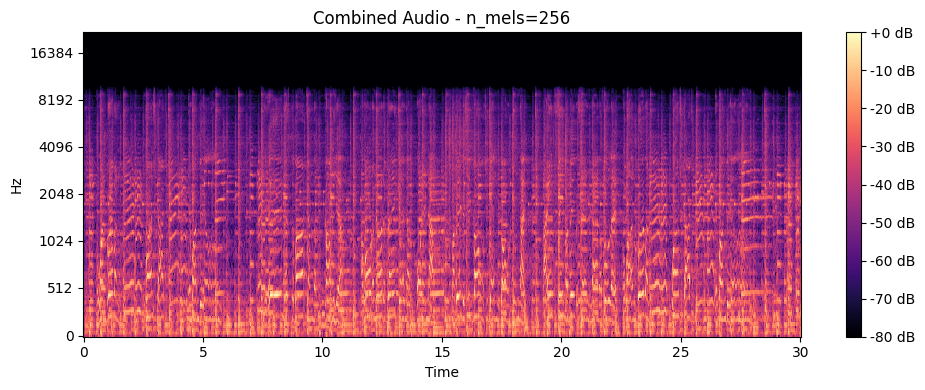

/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


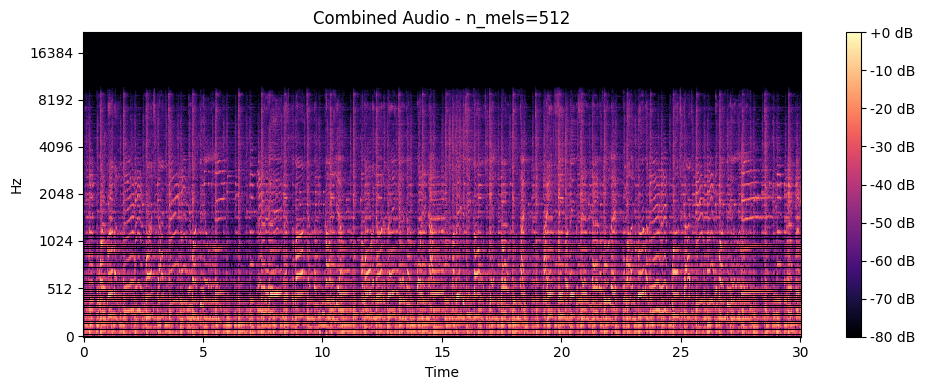

In [8]:
for n in [64, 128, 256, 512]:
    plot_mel(combined_audio, sr, f"Combined Audio - n_mels={n}", n_mels=n)
